In [1]:
!pip install natasha
!pip install pymorphy2
!pip install matplotlib
!pip install pandas
!pip install seaborn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    Doc
)
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("articles.csv")
df.tail(1)

,guid,title,description,url,published_at,comments_count,created_at_utc,rating
6773,4db15eee-6d27-4485-9f51-31c0b159b398,Появились ФОТО первой модели нового российског...,"Первой моделью, которую АВТОВАЗ начал выпускат...",https://news.drom.ru/XCITE-96106.html,2024-01-30,NaN,2025-12-19T11:26:30Z,NaN


In [4]:
print("Null: ", df["description"].isna().sum())
print("NUnique: ", len(df)-df["description"].nunique())

Null:  0
NUnique:  36


In [5]:
df = df.drop_duplicates(subset=["description"])
print("Now NUnique:", len(df)-df["description"].nunique())

Now NUnique: 0


### Инициализирование инструментов Natasha, pymorphy. Разбиение статьи на предложения.

In [6]:
segmenter = Segmenter()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)

morph_vocab = MorphVocab()

In [7]:
def split_sentences(text):
    doc = Doc(text)
    doc.segment(segmenter)
    sentences = []
    for sent in doc.sents:
        sentences.append(sent.text)
    return sentences


In [9]:
sentences = []

for text in df["description"]:
    sentences.extend(split_sentences(text))
sentences[:10]

['В ноябре в Госдуме приняли закон, направленный на решение вопроса кадрового дефицита, в народе известный как закон об отработках для студентов-медиков.',
 'Теперь после окончания обучения ребятам необходимо будет отработать до трёх лет в медицинских учреждениях, а учиться на ординатуре, иначе как по целевому набору, не получится.',
 'В медицинских вузах Владивостока закон скорее поддерживают.',
 'Считают, что он увеличит количество действительно мотивированной молодёжи.',
 'Сами студенты переживают, что их обучение сильно затянется, превратившись в кабалу, а как именно будут проходить отработки, до сих пор непонятно.',
 'Вступает в силу закон 1 марта следующего года, тогда же должны быть опубликованы приказы Минздрава РФ, разъясняющие всю его суть.',
 'Фактически новый закон – это расширение полномочий министерства без конкретики.',
 'Как из-за него изменится жизнь медиков, разбирались Новости VL.ru.',
 '«Преодоление кадрового дефицита»\n11 ноября Госдума приняла в третьем чтении зак

In [10]:
print("Count setences:", len(sentences))

Count setences: 163871


### Выделяем подлежащее и сказуемое с предложений.

In [11]:
def extract_subject_predicate(sentence):
    doc = Doc(sentence)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    doc.parse_syntax(syntax_parser)

    pairs = []
    tokens = {token.id: token for token in doc.tokens}

    for token in doc.tokens:
        token.lemmatize(morph_vocab)
        if token.rel == "nsubj" and token.pos == "NOUN":
            subject = token.lemma.lower()
            head = tokens.get(token.head_id)
            if head and head.pos == "VERB":
                head.lemmatize(morph_vocab)
                predicate = head.lemma.lower()
                pairs.append((subject, predicate))
    return pairs

In [12]:
extract_subject_predicate(sentences[-1])

[('автопоток', 'отмечать'), ('санкция', 'действовать')]

In [13]:
pairs = []

for sent in sentences:
    pairs.extend(extract_subject_predicate(sent))
pairs[:20]

[('закон', 'поддерживать'),
 ('студент', 'переживать'),
 ('обучение', 'затянуться'),
 ('закон', 'вступать'),
 ('жизнь', 'измениться'),
 ('время', 'сопровождать'),
 ('критика', 'сопровождать'),
 ('законотворец', 'объяснять'),
 ('выпускник', 'работать'),
 ('закон', 'менять'),
 ('целевик', 'позволить'),
 ('закон', 'предполагать'),
 ('вуз', 'иметь'),
 ('студент', 'ответить'),
 ('закон', 'подписать'),
 ('человек', 'обучаться'),
 ('вакансия', 'быть'),
 ('многие', 'говорить'),
 ('врач', 'нести'),
 ('выпускник', 'делиться')]

In [14]:
print("Count Pairs: ", len(pairs))

Count Pairs:  104978


### Самые частые сочетания

In [15]:
pair_counter = Counter(pairs)
top_pairs = pair_counter.most_common(50)

pairs_df = pd.DataFrame(top_pairs, columns=["pair", "count"])
pairs_df["subject"] = pairs_df["pair"].apply(lambda x: x[0])
pairs_df["predicate"] = pairs_df["pair"].apply(lambda x: x[1])
pairs_df = pairs_df.drop(columns=["pair"])

pairs_df.head(20)

,count,subject,predicate
0,309,речь,идти
1,265,рейс,задерживаться
2,182,газета,сообщать
3,138,продажа,стартовать
4,100,длина,составлять
5,86,пользователь,мочь
6,86,проблема,быть
7,83,возможность,быть
8,81,вопрос,возникать
9,79,объем,составить


### Визуализируем результаты

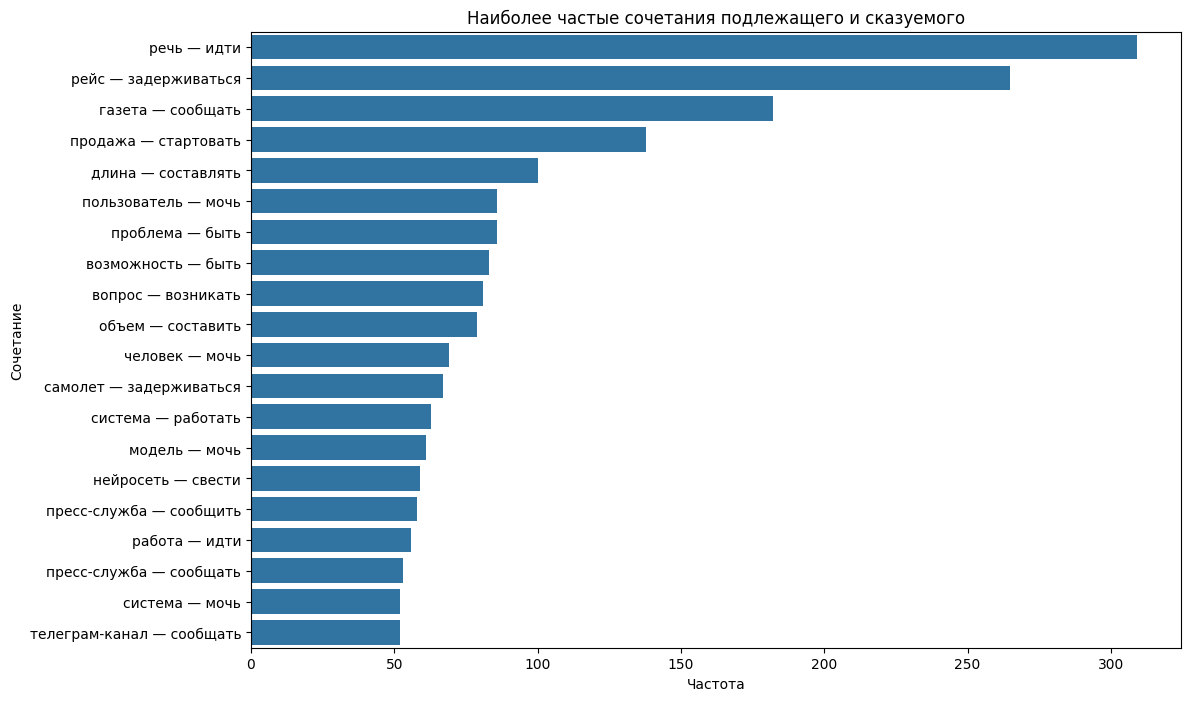

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

labels = pairs_df.head(20).apply(
    lambda x: f"{x.subject} — {x.predicate}", axis=1
)

sns.barplot(
    x=pairs_df.head(20)["count"],
    y=labels
)
plt.title("Наиболее частые сочетания подлежащего и сказуемого")
plt.xlabel("Частота")
plt.ylabel("Сочетание")

plt.show()